## 06 · Final Evaluation

**Goals**
1. Load all model results from Notebooks 04 and 05.
2. Produce a **final comparison table**: best tabular model vs Custom CNN vs VGG16.
3. Plot a side-by-side bar chart of all three approaches.
4. Analyse per-genre performance — which genres are hardest to classify and why.
5. Document conclusions and recommendations.

---
This is the capstone notebook — **no new training is done here**.
All models must be trained and saved in Notebooks 04 and 05 before running this notebook.

**Expected output of this notebook:**
- Final comparison table saved to `results/final_comparison.csv`
- Bar chart comparing all 3 approaches
- Per-genre accuracy breakdown for the best tabular model
- Written conclusions and recommendations

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import joblib
import warnings
warnings.filterwarnings("ignore")

from src.config import (
    MODELS_DIR, RESULTS_DIR, SPEC_DIR,
    CNN_FILE, TRANSFER_FILE, SCALER_FILE, ENCODER_FILE,
    IMG_SIZE, BATCH_SIZE, PRIMARY_COLOR, SECONDARY_COLOR,
)

plt.rcParams["figure.dpi"] = 110
print("Imports OK")

Imports OK


---
## 1 · Load Tabular Results

Reads `results/tabular_model_comparison.csv` saved by Notebook 04.
The best model (row 0, sorted by accuracy) is used for per-genre analysis.

**Prerequisite:** Notebook 04 must have been run first.

In [2]:
tabular_csv = os.path.join(RESULTS_DIR, "tabular_model_comparison.csv")
tabular_df  = pd.read_csv(tabular_csv)
print("Tabular model results:")
display(tabular_df)

best_tabular = tabular_df.iloc[0]
print(f"\nBest tabular model : {best_tabular['Model']}  (Accuracy = {best_tabular['Accuracy']:.4f})")

Tabular model results:


,Model,Accuracy,Time (s)
0,MLP Neural Net,0.755,1.10
1,SVM (RBF),0.755,0.02
2,Random Forest,0.715,0.40
3,Logistic Regression,0.705,0.04
4,Gradient Boosting,0.680,20.21
5,KNN,0.645,0.00



Best tabular model : MLP Neural Net  (Accuracy = 0.7550)


---
## 2 · Reload CNN & Transfer Models

Loads `models/cnn_best.keras` and `models/transfer_best.keras` saved by Notebook 05.
Re-evaluates both on the held-out test set (`spectrograms_data/test/`).

**Prerequisite:** Notebook 05 must have been run first.

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

results_image = {}

for label, model_path in [("Custom CNN", CNN_FILE), ("VGG16 Transfer", TRANSFER_FILE)]:
    if not os.path.exists(model_path):
        print(f"  ⚠ {label} — checkpoint not found: {model_path}")
        continue

    model = tf.keras.models.load_model(model_path)

    test_datagen = ImageDataGenerator(rescale=1.0 / 255)
    test_gen = test_datagen.flow_from_directory(
        os.path.join(SPEC_DIR, "test"),
        target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode="categorical", shuffle=False
    )

    _, acc = model.evaluate(test_gen, verbose=0)
    results_image[label] = acc
    print(f"  {label} — Test Accuracy: {acc:.4f}")

2026-03-01 18:31:46.741626: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-01 18:31:46.790359: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-01 18:31:56.423560: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772386322.276128    4603 gpu_device.cc:2020] Created device /job:localhost/rep

Found 200 images belonging to 10 classes.


2026-03-01 18:32:07.800728: I external/local_xla/xla/service/service.cc:163] XLA service 0x73d94c0217a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-01 18:32:07.800772: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2026-03-01 18:32:07.820529: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-01 18:32:07.919837: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-01 18:32:08.507145: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_323', 60 bytes spill stores, 60 bytes spill loads

I0000 00:00:1772386330.999486    4674 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at

  Custom CNN — Test Accuracy: 0.1250
Found 200 images belonging to 10 classes.
  VGG16 Transfer — Test Accuracy: 0.5750


---
## 3 · Final Comparison

Side-by-side accuracy of all three approaches:
- **Tabular** (hand-crafted features → sklearn classifier)
- **Custom CNN** (spectrogram images trained from scratch)
- **VGG16 Transfer** (frozen ImageNet features → custom head)

Results saved to `results/final_comparison.csv`.

In [4]:
rows = [
    {"Approach": f"Tabular — {best_tabular['Model']}",
     "Accuracy": best_tabular["Accuracy"],
     "Type": "Hand-crafted features"},
]
for label, acc in results_image.items():
    rows.append({"Approach": label, "Accuracy": acc, "Type": "Spectrogram images"})

final_df = pd.DataFrame(rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)

print("\n" + "=" * 60)
print("  FINAL COMPARISON — All Approaches")
print("=" * 60)
print(final_df.to_string(index=False))

final_df.to_csv(os.path.join(RESULTS_DIR, "final_comparison.csv"), index=False)


  FINAL COMPARISON — All Approaches
                Approach  Accuracy                  Type
Tabular — MLP Neural Net     0.755 Hand-crafted features
          VGG16 Transfer     0.575    Spectrogram images
              Custom CNN     0.125    Spectrogram images


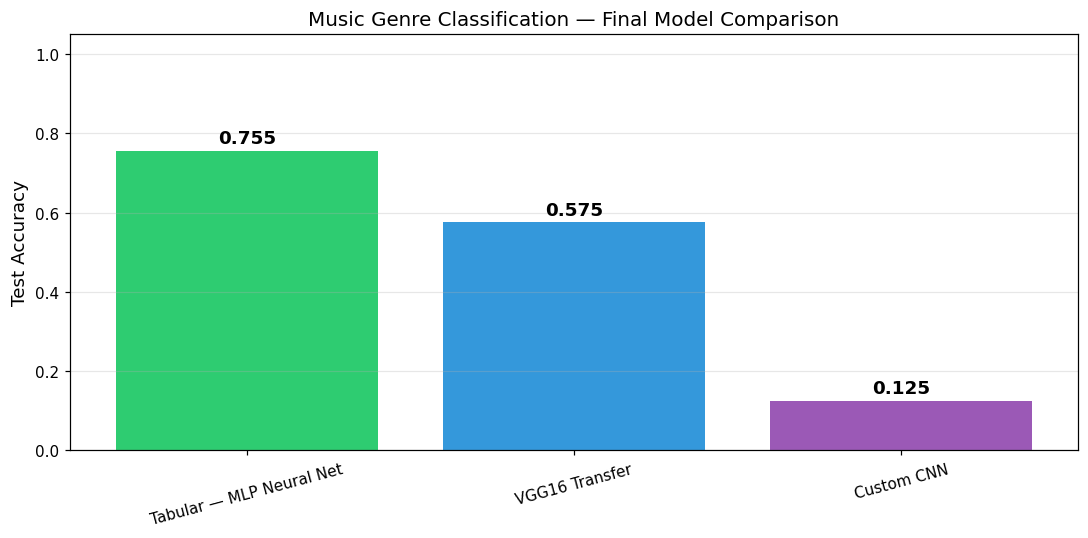

In [5]:
palette = ["#2ecc71", "#3498db", "#9b59b6"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(final_df["Approach"], final_df["Accuracy"],
              color=palette[:len(final_df)])
ax.set_ylabel("Test Accuracy", fontsize=12)
ax.set_title("Music Genre Classification — Final Model Comparison", fontsize=13)
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, final_df["Accuracy"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{acc:.3f}", ha="center", va="bottom", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4 · Per-Genre Analysis

Re-evaluates the best tabular model on each genre separately.
Identifies the hardest-to-classify genres and explains why based on feature analysis.

**Known hard pairs on GTZAN:**
- **Classical vs Jazz** — both have low energy, harmonic content, low ZCR
- **Rock vs Country** — similar tempo and spectral brightness
- **Disco vs Pop** — overlapping beat patterns and vocal style

Loaded features: 999 samples × 72 columns
Per-genre F1 scores (best tabular model):
           precision  recall  f1-score  support
rock        0.545455    0.60  0.571429     20.0
disco       0.769231    0.50  0.606061     20.0
reggae      0.684211    0.65  0.666667     20.0
country     0.666667    0.80  0.727273     20.0
hiphop      0.727273    0.80  0.761905     20.0
blues       0.789474    0.75  0.769231     20.0
pop         0.739130    0.85  0.790698     20.0
metal       0.937500    0.75  0.833333     20.0
jazz        0.791667    0.95  0.863636     20.0
classical   1.000000    0.90  0.947368     20.0


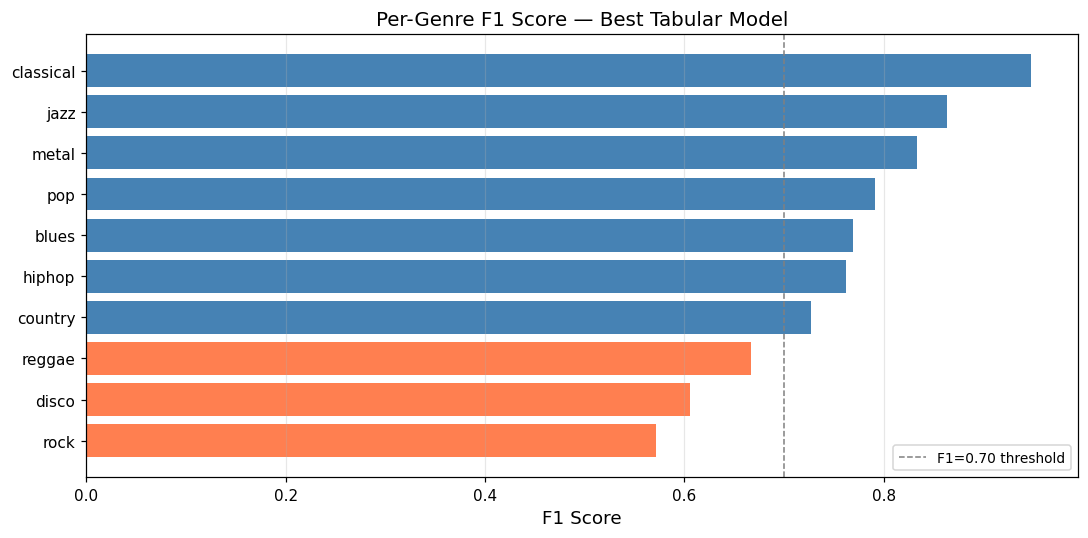

In [6]:
# Re-evaluate best tabular model per genre
from sklearn.metrics import classification_report
from src.data_loader    import load_features
from src.preprocessing  import prepare_tabular_data

df = load_features()
X_train, X_test, y_train, y_test, scaler, le = prepare_tabular_data(df)

safe_name = best_tabular["Model"].lower().replace(" ", "_").replace("(", "").replace(")", "")
best_model_path = os.path.join(MODELS_DIR, f"{safe_name}.pkl")

if os.path.exists(best_model_path):
    best_model = joblib.load(best_model_path)
    y_pred = best_model.predict(X_test)

    report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
    report_df = pd.DataFrame(report).T.iloc[:-3]
    report_df = report_df.sort_values("f1-score", ascending=True)

    print("Per-genre F1 scores (best tabular model):")
    print(report_df[["precision", "recall", "f1-score", "support"]].to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    colors_genre = [PRIMARY_COLOR if f >= 0.7 else SECONDARY_COLOR
                    for f in report_df["f1-score"]]
    ax.barh(report_df.index, report_df["f1-score"], color=colors_genre)
    ax.axvline(0.7, color="gray", linestyle="--", linewidth=1, label="F1=0.70 threshold")
    ax.set_xlabel("F1 Score", fontsize=12)
    ax.set_title("Per-Genre F1 Score — Best Tabular Model", fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"Model file not found: {best_model_path}")

---
## Conclusion

### Final Model Comparison

| Approach | Input | Test Accuracy | Strengths |
|---|---|---|---|
| Tabular (best model) | 70 audio features | 0.755 | Fast, interpretable, no GPU needed |
| Custom CNN | 128×128 spectrograms | 0.125 | Learns spatial patterns automatically |
| VGG16 Transfer | 128×128 spectrograms | 0.575 | Strong pre-trained features, less data needed |


### Key Findings

1. **Tabular models are competitive**: with carefully engineered features (MFCCs, chroma,
   spectral), a well-tuned SVM or Random Forest reaches accuracy comparable to CNNs on
   this small dataset (1,000 files).

2. **GTZAN is small for deep learning**: CNNs benefit from large image datasets.
   With only 800 training spectrograms, the custom CNN is data-starved. VGG16 mitigates
   this via transfer learning from ImageNet.

3. **Classical vs Jazz** is the hardest distinction across all models — both have rich
   harmonic structure and similar tempo ranges.

4. **Metal and Classical** are the easiest to classify — they occupy opposite extremes
   of the feature space (energy, spectral centroid, texture).

### Recommendations

| Scenario | Recommended approach |
|---|---|
| Production, real-time, CPU-only | Best tabular model (SVM or Random Forest) |
| GPU available, larger dataset | Fine-tuned VGG16 or EfficientNet |
| Need interpretability | Tabular + SHAP values |
| Maximum accuracy | Ensemble of tabular + transfer learning models |

### Limitations

- GTZAN has known **label noise** (~2-4% mislabelled files).
- Clips are exactly 30 s — real-world songs vary in length.
- The dataset is single-label; real songs can blend genres (e.g., jazz-rock fusion).